In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [2]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment_since', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installment',
    'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker',
    'target'
]
df = pd.read_csv(url, sep=' ', names=columns)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset loaded!
Shape: (1000, 21)

First 5 rows:
  checking_account  duration credit_history purpose  credit_amount  \
0              A11         6            A34     A43           1169   
1              A12        48            A32     A43           5951   
2              A14        12            A34     A46           2096   
3              A11        42            A32     A42           7882   
4              A11        24            A33     A40           4870   

  savings_account employment_since  installment_rate personal_status  \
0             A65              A75                 4             A93   
1             A61              A73                 2             A92   
2             A61              A74                 2             A93   
3             A61              A74                 2             A93   
4             A61              A73                 3             A93   

  other_debtors  ...  property age  other_installment housing  \
0          A101  ...      A121  

In [3]:
print("LOAN APPROVAL DATASET - EXPLORATORY ANALYSIS")

print("\n1. DATASET OVERVIEW")
print(f"Total applications: {len(df)}")
print(f"Features: {len(df.columns) - 1}")

print("\n2. TARGET VARIABLE")
print(df['target'].value_counts())
print("\nPercentages:")
print(df['target'].value_counts(normalize=True) * 100)

# Target is coded as 1=Good, 2=Bad
# Let's recode: 1=Approved (Good), 0=Rejected (Bad)
df['target'] = df['target'].map({1: 1, 2: 0})  # 1=Good, 2=Bad → 1=Approve, 0=Reject

print("\n After recoding:")
print("1 = APPROVE (good credit, repaid loan)")
print("0 = REJECT (bad credit, defaulted)")
print(df['target'].value_counts())

print("\n3. FEATURE DESCRIPTIONS")
print("\n Numerical Features:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('target')
print(numerical_cols)

print("\n Categorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

print("\n4. MISSING VALUES")
print(df.isnull().sum().sum())
if df.isnull().sum().sum() == 0:
    print(" No missing values!")

print("\n5. BASIC STATISTICS")
print(df[numerical_cols].describe())

LOAN APPROVAL DATASET - EXPLORATORY ANALYSIS

1. DATASET OVERVIEW
Total applications: 1000
Features: 20

2. TARGET VARIABLE
target
1    700
2    300
Name: count, dtype: int64

Percentages:
target
1    70.0
2    30.0
Name: proportion, dtype: float64

 After recoding:
1 = APPROVE (good credit, repaid loan)
0 = REJECT (bad credit, defaulted)
target
1    700
0    300
Name: count, dtype: int64

3. FEATURE DESCRIPTIONS

 Numerical Features:
['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']

 Categorical Features:
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status', 'other_debtors', 'property', 'other_installment', 'housing', 'job', 'telephone', 'foreign_worker']

4. MISSING VALUES
0
 No missing values!

5. BASIC STATISTICS
          duration  credit_amount  installment_rate  residence_since  \
count  1000.000000    1000.000000       1000.000000      1000.000000   
mean     2


FEATURE MEANINGS

checking_account:
  Status of checking account (A11=<0 DM, A12=0-200, A13=>200, A14=none)
  Unique values: 4

duration:
  Loan duration in months
  Unique values: 33

credit_history:
  Past credit behavior (A30=all paid, A31=paid this bank, A32=existing paid, A33=delay, A34=critical)
  Unique values: 5

purpose:
  Loan purpose (A40=car new, A41=car used, A42=furniture, A43=TV, etc.)
  Unique values: 10

credit_amount:
  Loan amount in DM (Deutsche Mark)
  Unique values: 921

savings_account:
  Savings account balance (A61=<100, A62=100-500, A63=500-1000, A64=>1000, A65=unknown)
  Unique values: 5

employment_since:
  Years employed (A71=unemployed, A72=<1yr, A73=1-4yr, A74=4-7yr, A75=>7yr)
  Unique values: 5

installment_rate:
  Installment rate as % of disposable income
  Unique values: 4

personal_status:
  Gender and marital status
  Unique values: 4

other_debtors:
  Other debtors/guarantors (A101=none, A102=co-applicant, A103=guarantor)
  Unique values: 3

resid

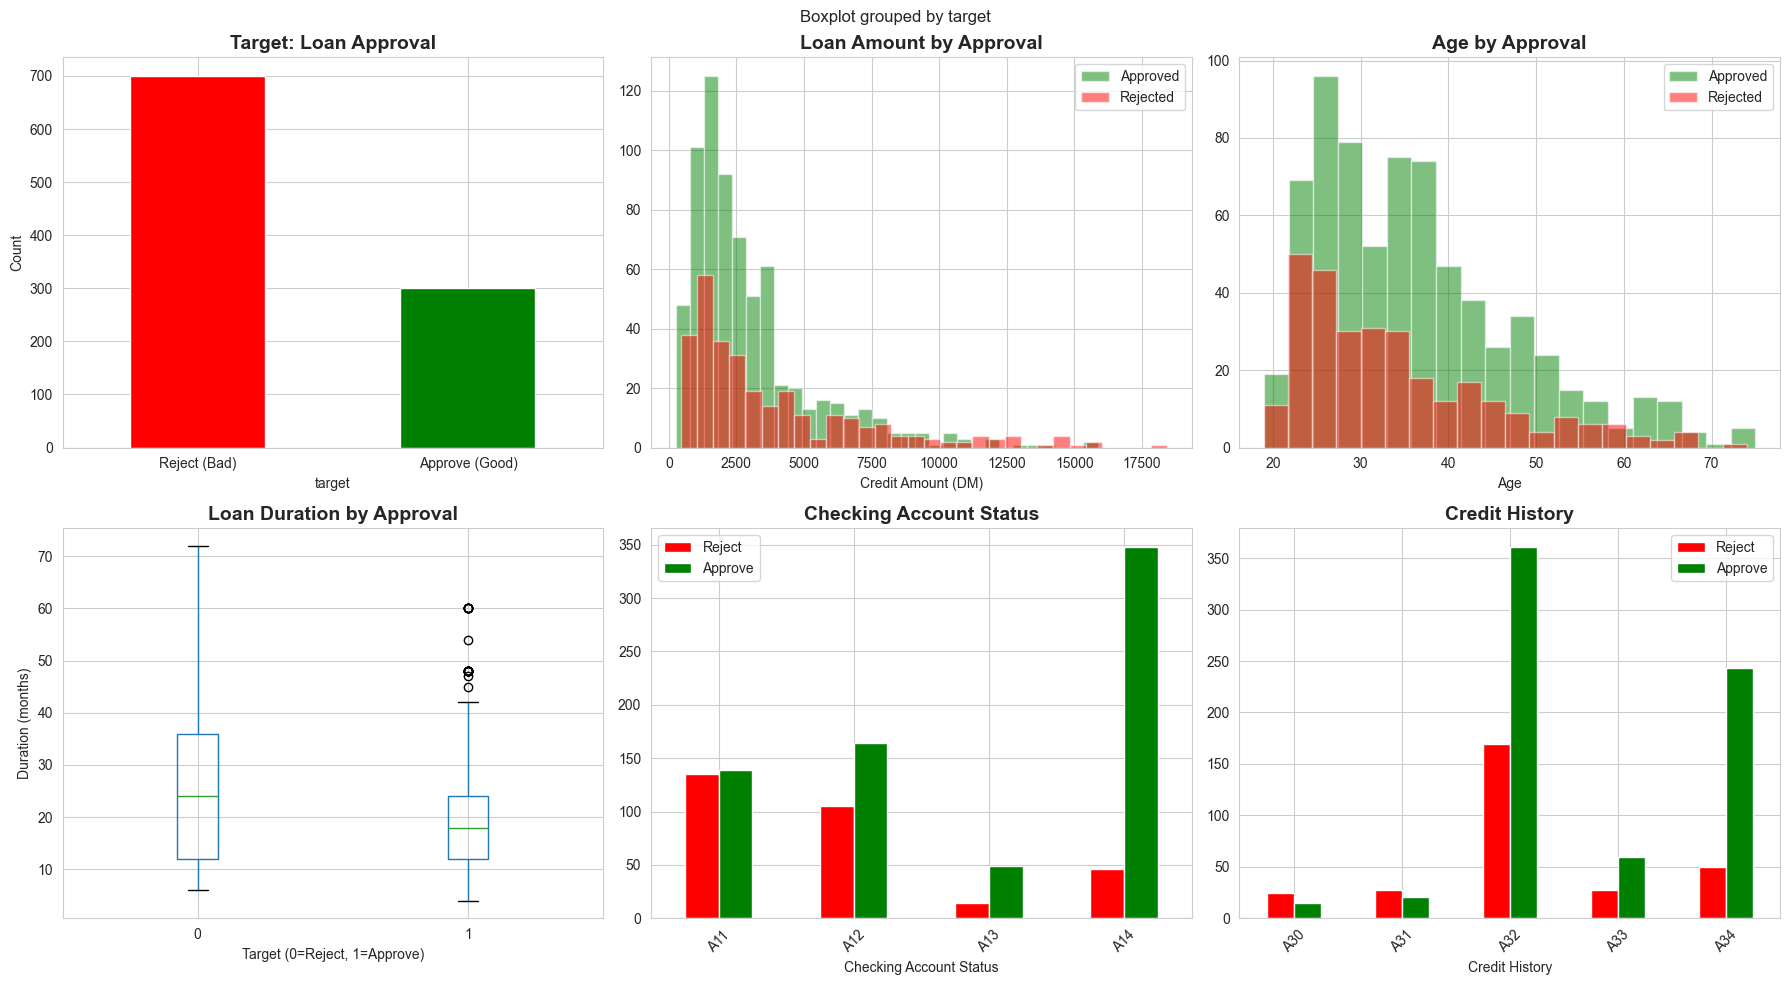


 Visualizations created!


In [4]:
# ============================================================================
# UNDERSTAND EACH FEATURE
# ============================================================================

print("\n" + "="*70)
print("FEATURE MEANINGS")
print("="*70)

feature_meanings = {
    'checking_account': 'Status of checking account (A11=<0 DM, A12=0-200, A13=>200, A14=none)',
    'duration': 'Loan duration in months',
    'credit_history': 'Past credit behavior (A30=all paid, A31=paid this bank, A32=existing paid, A33=delay, A34=critical)',
    'purpose': 'Loan purpose (A40=car new, A41=car used, A42=furniture, A43=TV, etc.)',
    'credit_amount': 'Loan amount in DM (Deutsche Mark)',
    'savings_account': 'Savings account balance (A61=<100, A62=100-500, A63=500-1000, A64=>1000, A65=unknown)',
    'employment_since': 'Years employed (A71=unemployed, A72=<1yr, A73=1-4yr, A74=4-7yr, A75=>7yr)',
    'installment_rate': 'Installment rate as % of disposable income',
    'personal_status': 'Gender and marital status',
    'other_debtors': 'Other debtors/guarantors (A101=none, A102=co-applicant, A103=guarantor)',
    'residence_since': 'Years at current residence',
    'property': 'Property owned (A121=real estate, A122=savings/insurance, A123=car, A124=none)',
    'age': 'Age in years',
    'other_installment': 'Other installment plans (A141=bank, A142=stores, A143=none)',
    'housing': 'Housing status (A151=rent, A152=own, A153=free)',
    'existing_credits': 'Number of existing credits at this bank',
    'job': 'Job category (A171=unemployed, A172=unskilled, A173=skilled, A174=highly skilled)',
    'num_dependents': 'Number of people liable to provide maintenance',
    'telephone': 'Has telephone (A191=none, A192=yes)',
    'foreign_worker': 'Is foreign worker (A201=yes, A202=no)'
}

for feature, meaning in feature_meanings.items():
    print(f"\n{feature}:")
    print(f"  {meaning}")
    if feature in df.columns:
        print(f"  Unique values: {df[feature].nunique()}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0,0], color=['red', 'green'])
axes[0,0].set_title('Target: Loan Approval', fontsize=14, fontweight='bold')
axes[0,0].set_xticklabels(['Reject (Bad)', 'Approve (Good)'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Loan amount distribution
axes[0,1].hist(df[df['target']==1]['credit_amount'], bins=30, alpha=0.5, label='Approved', color='green')
axes[0,1].hist(df[df['target']==0]['credit_amount'], bins=30, alpha=0.5, label='Rejected', color='red')
axes[0,1].set_title('Loan Amount by Approval', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Credit Amount (DM)')
axes[0,1].legend()

# 3. Age distribution
axes[0,2].hist(df[df['target']==1]['age'], bins=20, alpha=0.5, label='Approved', color='green')
axes[0,2].hist(df[df['target']==0]['age'], bins=20, alpha=0.5, label='Rejected', color='red')
axes[0,2].set_title('Age by Approval', fontsize=14, fontweight='bold')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# 4. Duration
df.boxplot(column='duration', by='target', ax=axes[1,0])
axes[1,0].set_title('Loan Duration by Approval', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Target (0=Reject, 1=Approve)')
axes[1,0].set_ylabel('Duration (months)')

# 5. Checking account status
if 'checking_account' in df.columns:
    pd.crosstab(df['checking_account'], df['target']).plot(kind='bar', ax=axes[1,1], color=['red', 'green'])
    axes[1,1].set_title('Checking Account Status', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Checking Account Status')
    axes[1,1].legend(['Reject', 'Approve'])
    axes[1,1].tick_params(axis='x', rotation=45)

# 6. Credit history
if 'credit_history' in df.columns:
    pd.crosstab(df['credit_history'], df['target']).plot(kind='bar', ax=axes[1,2], color=['red', 'green'])
    axes[1,2].set_title('Credit History', fontsize=14, fontweight='bold')
    axes[1,2].set_xlabel('Credit History')
    axes[1,2].legend(['Reject', 'Approve'])
    axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('loan_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualizations created!")

In [5]:

print("FEATURE ENGINEERING")

df_processed = df.copy()

# 1. Create age groups
df_processed['age_group'] = pd.cut(
    df_processed['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)
print("\n1. Created age_group feature")

# 2. Loan amount categories
df_processed['loan_size'] = pd.cut(
    df_processed['credit_amount'],
    bins=[0, 2000, 5000, 10000, float('inf')],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)
print("2. Created loan_size feature")

# 3. Duration categories
df_processed['loan_term'] = pd.cut(
    df_processed['duration'],
    bins=[0, 12, 24, 36, float('inf')],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)
print("3. Created loan_term feature")

# 4. Debt-to-duration ratio (how much per month)
df_processed['monthly_payment'] = df_processed['credit_amount'] / df_processed['duration']
print("4. Created monthly_payment feature")

# 5. Credit utilization indicator
# Installment rate is % of disposable income
df_processed['high_burden'] = (df_processed['installment_rate'] >= 3).astype(int)
print("5. Created high_burden feature (1 if installment_rate >= 3)")

# 6. Risk score based on checking account
checking_risk = {
    'A11': 3,  # < 0 DM (negative balance - HIGH RISK)
    'A12': 2,  # 0 to 200 DM
    'A13': 1,  # >= 200 DM
    'A14': 2   # no checking account
}
df_processed['checking_risk'] = df_processed['checking_account'].map(checking_risk)
print("6. Created checking_risk score")

# 7. Savings risk score
savings_risk = {
    'A61': 3,  # < 100 DM
    'A62': 2,  # 100 to 500
    'A63': 1,  # 500 to 1000
    'A64': 0,  # >= 1000
    'A65': 2   # unknown
}
df_processed['savings_risk'] = df_processed['savings_account'].map(savings_risk)
print("7. Created savings_risk score")

# 8. Employment stability score
employment_score = {
    'A71': 3,  # unemployed (HIGH RISK)
    'A72': 2,  # < 1 year
    'A73': 1,  # 1 to 4 years
    'A74': 0,  # 4 to 7 years
    'A75': 0   # >= 7 years (STABLE)
}
df_processed['employment_stability'] = df_processed['employment_since'].map(employment_score)
print("8. Created employment_stability score")

print(f"\n Feature engineering complete!")
print(f"Original features: {df.shape[1]}")
print(f"New features: {df_processed.shape[1]}")
print(f"Added: {df_processed.shape[1] - df.shape[1]} features")

print("\nNew features preview:")
print(df_processed[['age', 'age_group', 'credit_amount', 'loan_size', 
                     'monthly_payment', 'checking_risk', 'savings_risk']].head())

FEATURE ENGINEERING

1. Created age_group feature
2. Created loan_size feature
3. Created loan_term feature
4. Created monthly_payment feature
5. Created high_burden feature (1 if installment_rate >= 3)
6. Created checking_risk score
7. Created savings_risk score
8. Created employment_stability score

 Feature engineering complete!
Original features: 21
New features: 29
Added: 8 features

New features preview:
   age age_group  credit_amount loan_size  monthly_payment  checking_risk  \
0   67       55+           1169     Small       194.833333              3   
1   22     18-25           5951     Large       123.979167              2   
2   49     46-55           2096    Medium       174.666667              2   
3   45     36-45           7882     Large       187.666667              3   
4   53     46-55           4870    Medium       202.916667              3   

   savings_risk  
0             2  
1             3  
2             3  
3             3  
4             3  


In [6]:

print("DATA PREPROCESSING")

# Separate features and target
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print(f"\n Features: {X.shape}")
print(f"Target: {y.shape}")

# Identify column types
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical features ({len(categorical_features)}): {categorical_features[:5]}...")
print(f"Numerical features ({len(numerical_features)}): {numerical_features[:5]}...")

# Encode categorical variables
le_dict = {}
X_encoded = X.copy()

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le
    
print(f"\n Encoded {len(categorical_features)} categorical features")

# Handle any missing or inf values
X_encoded = X_encoded.replace([np.inf, -np.inf], np.nan)
X_encoded = X_encoded.fillna(X_encoded.median())

print(f" Handled missing values")
print(f"Final shape: {X_encoded.shape}")
print(f"NaN count: {X_encoded.isnull().sum().sum()}")

# Train-test split (70-30 for smaller dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"\nTrain set: {X_train.shape} (70%)")
print(f"Test set: {X_test.shape} (30%)")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Safety check
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n Data scaled and ready!")
print(f"Scaled data NaN check: {np.isnan(X_train_scaled).sum()}")

DATA PREPROCESSING

 Features: (1000, 28)
Target: (1000,)

Categorical features (16): ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since']...
Numerical features (12): ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age']...

 Encoded 16 categorical features
 Handled missing values
Final shape: (1000, 28)
NaN count: 0

Train set: (700, 28) (70%)
Test set: (300, 28) (30%)

Train target distribution:
target
1    0.7
0    0.3
Name: proportion, dtype: float64

 Data scaled and ready!
Scaled data NaN check: 0


In [7]:

def evaluate_loan_model(name, y_true, y_pred, y_pred_proba):
    """
    Evaluate loan approval model
    
    Special consideration:
    - False Negative (reject good customer) = Lost business
    - False Positive (approve bad customer) = Loan default ($10K loss)
    
    False Positives are MORE COSTLY!
    """
    print(f"{name.upper()} - RESULTS")
  
    
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n PERFORMANCE METRICS:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (of approved loans, {precision*100:.1f}% are good)")
    print(f"Recall:    {recall:.4f} (we approve {recall*100:.1f}% of all good customers)")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n CONFUSION MATRIX:")
    print(cm)
    
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n True Negatives (TN):  {tn} - Correctly rejected bad customers")
    print(f" False Positives (FP): {fp} - WRONGLY approved bad customers (COSTLY!)")
    print(f" False Negatives (FN): {fn} - WRONGLY rejected good customers (lost business)")
    print(f" True Positives (TP):  {tp} - Correctly approved good customers")
    
    # Business impact
    loss_per_default = 10000
    profit_per_good_loan = 2000
    
    cost_of_fp = fp * loss_per_default
    cost_of_fn = fn * profit_per_good_loan
    profit_from_tp = tp * profit_per_good_loan
    
    net_profit = profit_from_tp - cost_of_fp - cost_of_fn
    
    print(f"\n BUSINESS IMPACT (estimated):")
    print(f"Losses from bad approvals (FP): ${cost_of_fp:,}")
    print(f"Lost profit from rejections (FN): ${cost_of_fn:,}")
    print(f"Profit from good approvals (TP): ${profit_from_tp:,}")
    print(f"NET PROFIT: ${net_profit:,}")
    
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Net_Profit': net_profit
    }

print(" Evaluation function defined!")

 Evaluation function defined!


In [8]:
print("MODEL 1: LOGISTIC REGRESSION - BASELINE")
# Train model
lr_model = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced'  # Handle slight imbalance
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
results_lr = evaluate_loan_model('Logistic Regression', y_test, y_pred_lr, y_pred_proba_lr)

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n Top 10 Most Important Features (Logistic Regression):")
print(feature_importance_lr.head(10))

print("\n" + "="*70)
print(" INTERPRETATION:")
print("="*70)
print("Positive coefficient = Increases approval chance")
print("Negative coefficient = Decreases approval chance")
print("\nTop positive (good for approval):")
for idx, row in feature_importance_lr.head(3).iterrows():
    if row['coefficient'] > 0:
        print(f"  {row['feature']}: +{row['coefficient']:.3f}")

print("\nTop negative (bad for approval):")
for idx, row in feature_importance_lr.tail(3).iterrows():
    if row['coefficient'] < 0:
        print(f"  {row['feature']}: {row['coefficient']:.3f}")

print("\n Logistic Regression Complete!")

MODEL 1: LOGISTIC REGRESSION - BASELINE
LOGISTIC REGRESSION - RESULTS

 PERFORMANCE METRICS:
Accuracy:  0.7467
Precision: 0.8722 (of approved loans, 87.2% are good)
Recall:    0.7476 (we approve 74.8% of all good customers)
F1-Score:  0.8051
ROC-AUC:   0.8026

 CONFUSION MATRIX:
[[ 67  23]
 [ 53 157]]

 True Negatives (TN):  67 - Correctly rejected bad customers
 False Positives (FP): 23 - WRONGLY approved bad customers (COSTLY!)
 False Negatives (FN): 53 - WRONGLY rejected good customers (lost business)
 True Positives (TP):  157 - Correctly approved good customers

 BUSINESS IMPACT (estimated):
Losses from bad approvals (FP): $230,000
Lost profit from rejections (FN): $106,000
Profit from good approvals (TP): $314,000
NET PROFIT: $-22,000

 Top 10 Most Important Features (Logistic Regression):
                 feature  coefficient
0       checking_account     0.759070
1               duration    -0.547829
27  employment_stability    -0.422111
23       monthly_payment    -0.404919
2  

MODEL 2: DECISION TREE
DECISION TREE - RESULTS

 PERFORMANCE METRICS:
Accuracy:  0.7067
Precision: 0.8631 (of approved loans, 86.3% are good)
Recall:    0.6905 (we approve 69.0% of all good customers)
F1-Score:  0.7672
ROC-AUC:   0.7372

 CONFUSION MATRIX:
[[ 67  23]
 [ 65 145]]

 True Negatives (TN):  67 - Correctly rejected bad customers
 False Positives (FP): 23 - WRONGLY approved bad customers (COSTLY!)
 False Negatives (FN): 65 - WRONGLY rejected good customers (lost business)
 True Positives (TP):  145 - Correctly approved good customers

 BUSINESS IMPACT (estimated):
Losses from bad approvals (FP): $230,000
Lost profit from rejections (FN): $130,000
Profit from good approvals (TP): $290,000
NET PROFIT: $-70,000

 Top 10 Most Important Features (Decision Tree):
             feature  importance
0   checking_account    0.498770
1           duration    0.108372
5    savings_account    0.079566
3            purpose    0.068850
23   monthly_payment    0.060967
9      other_debtors    

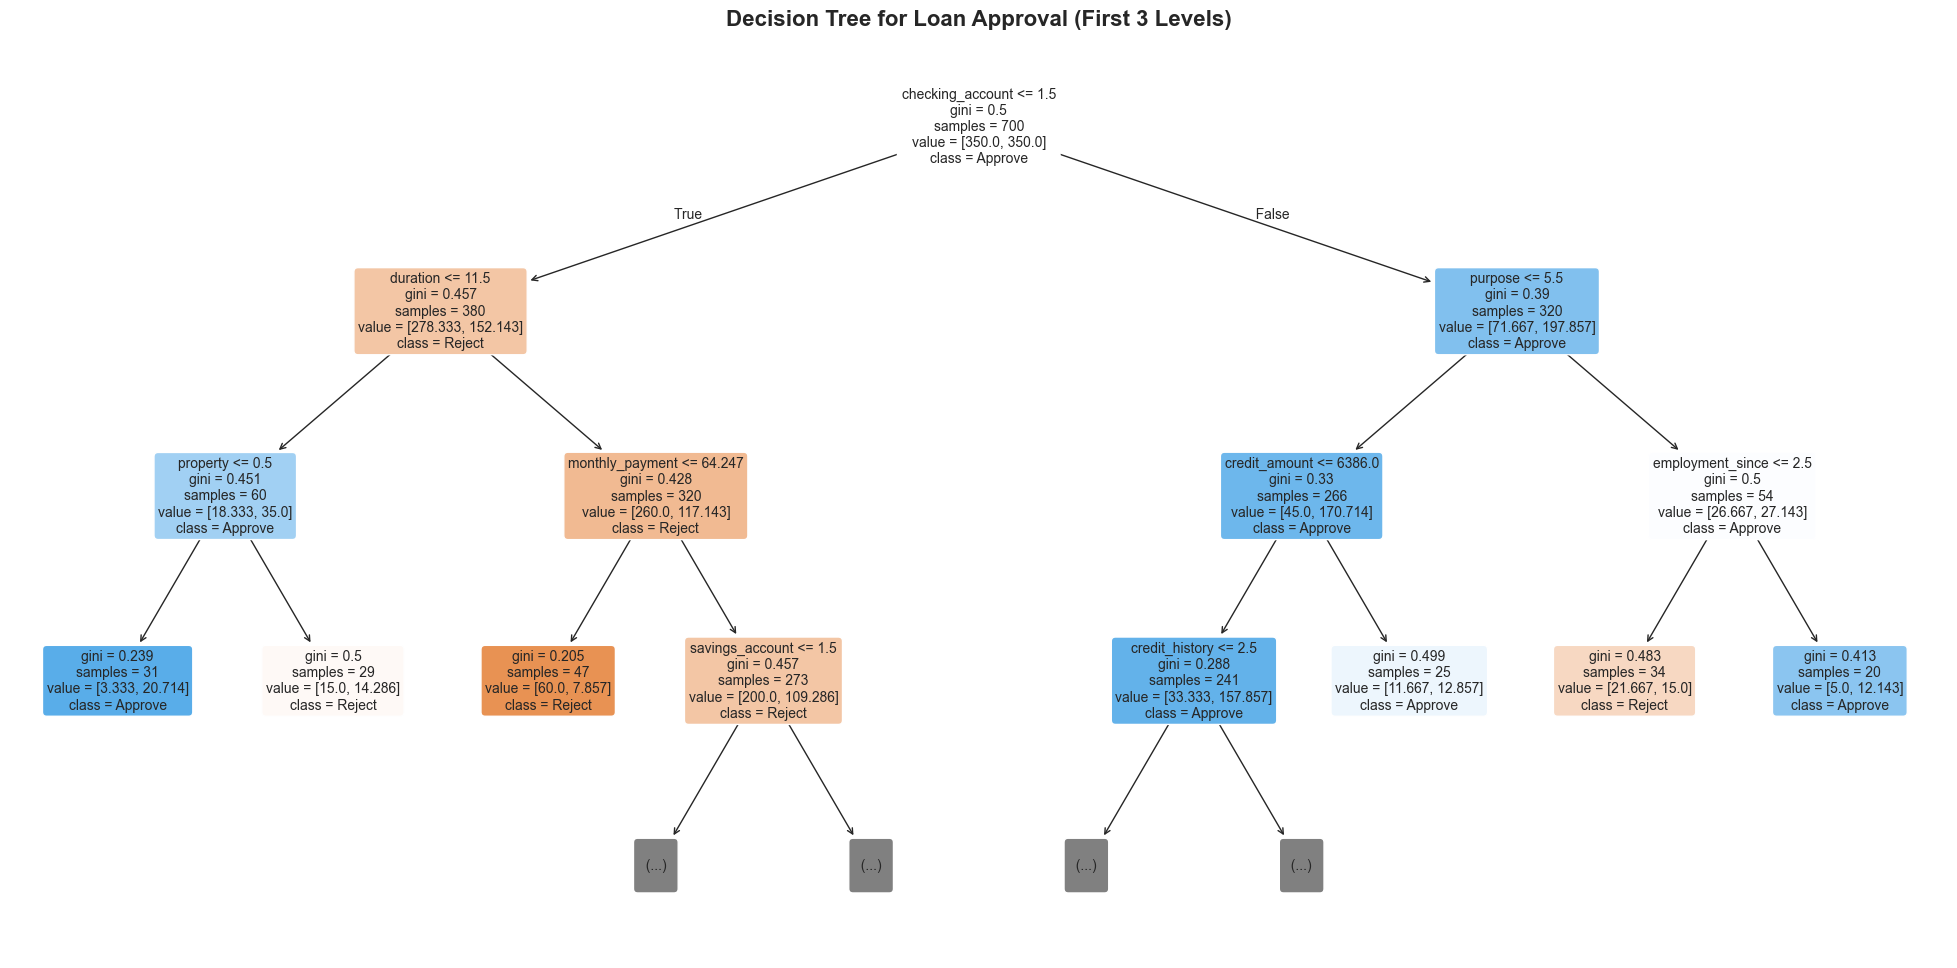


 Decision Tree Complete!


In [9]:
print("MODEL 2: DECISION TREE")

# Train model (using unscaled data - trees don't need scaling)
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,  # Limit depth to prevent overfitting
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
results_dt = evaluate_loan_model('Decision Tree', y_test, y_pred_dt, y_pred_proba_dt)

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Most Important Features (Decision Tree):")
print(feature_importance_dt.head(10))

# Visualize tree (first few levels)
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))
plot_tree(
    dt_model, 
    max_depth=3, 
    feature_names=X_encoded.columns,
    class_names=['Reject', 'Approve'],
    filled=True,
    fontsize=10,
    rounded=True
)
plt.title('Decision Tree for Loan Approval (First 3 Levels)', fontsize=16, fontweight='bold')
plt.savefig('loan_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Decision Tree Complete!")

MODEL 3: RANDOM FOREST
RANDOM FOREST - RESULTS

 PERFORMANCE METRICS:
Accuracy:  0.7533
Precision: 0.8505 (of approved loans, 85.1% are good)
Recall:    0.7857 (we approve 78.6% of all good customers)
F1-Score:  0.8168
ROC-AUC:   0.7899

 CONFUSION MATRIX:
[[ 61  29]
 [ 45 165]]

 True Negatives (TN):  61 - Correctly rejected bad customers
 False Positives (FP): 29 - WRONGLY approved bad customers (COSTLY!)
 False Negatives (FN): 45 - WRONGLY rejected good customers (lost business)
 True Positives (TP):  165 - Correctly approved good customers

 BUSINESS IMPACT (estimated):
Losses from bad approvals (FP): $290,000
Lost profit from rejections (FN): $90,000
Profit from good approvals (TP): $330,000
NET PROFIT: $-50,000

 Top 15 Most Important Features (Random Forest):
                 feature  importance
0       checking_account    0.182286
23       monthly_payment    0.088992
4          credit_amount    0.083767
1               duration    0.081507
25         checking_risk    0.070771
2

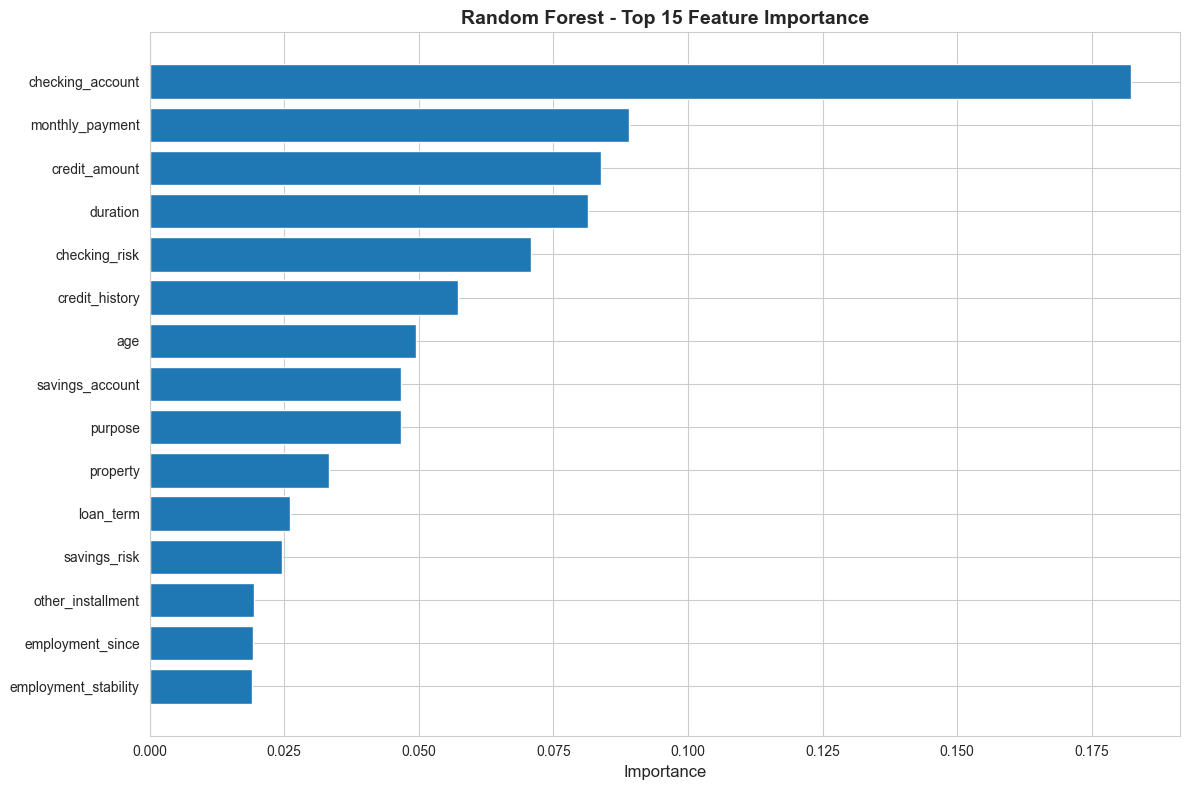


 Random Forest Complete!


In [10]:

print("MODEL 3: RANDOM FOREST")

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
results_rf = evaluate_loan_model('Random Forest', y_test, y_pred_rf, y_pred_proba_rf)

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features (Random Forest):")
print(feature_importance_rf.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_rf.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest - Top 15 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Random Forest Complete!")

In [11]:
print("MODEL 4: XGBOOST")

# Calculate scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Train model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
results_xgb = evaluate_loan_model('XGBoost', y_test, y_pred_xgb, y_pred_proba_xgb)

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(15))

print("\n XGBoost Complete!")

MODEL 4: XGBOOST
Scale pos weight: 0.43
XGBOOST - RESULTS

 PERFORMANCE METRICS:
Accuracy:  0.7233
Precision: 0.8009 (of approved loans, 80.1% are good)
Recall:    0.8048 (we approve 80.5% of all good customers)
F1-Score:  0.8029
ROC-AUC:   0.7606

 CONFUSION MATRIX:
[[ 48  42]
 [ 41 169]]

 True Negatives (TN):  48 - Correctly rejected bad customers
 False Positives (FP): 42 - WRONGLY approved bad customers (COSTLY!)
 False Negatives (FN): 41 - WRONGLY rejected good customers (lost business)
 True Positives (TP):  169 - Correctly approved good customers

 BUSINESS IMPACT (estimated):
Losses from bad approvals (FP): $420,000
Lost profit from rejections (FN): $82,000
Profit from good approvals (TP): $338,000
NET PROFIT: $-164,000

 Top 15 Most Important Features (XGBoost):
                 feature  importance
25         checking_risk    0.121443
0       checking_account    0.078666
26          savings_risk    0.054354
9          other_debtors    0.053678
2         credit_history    0.04

In [12]:
print("MODEL 5: CATBOOST")
# Train model
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],
    random_state=42,
    verbose=False
)

cat_model.fit(X_train, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_test)
y_pred_proba_cat = cat_model.predict_proba(X_test)[:, 1]

# Evaluate
results_cat = evaluate_loan_model('CatBoost', y_test, y_pred_cat, y_pred_proba_cat)

# Feature importance
feature_importance_cat = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features (CatBoost):")
print(feature_importance_cat.head(15))

print("\n CatBoost Complete!")

MODEL 5: CATBOOST
CATBOOST - RESULTS

 PERFORMANCE METRICS:
Accuracy:  0.7267
Precision: 0.8107 (of approved loans, 81.1% are good)
Recall:    0.7952 (we approve 79.5% of all good customers)
F1-Score:  0.8029
ROC-AUC:   0.7769

 CONFUSION MATRIX:
[[ 51  39]
 [ 43 167]]

 True Negatives (TN):  51 - Correctly rejected bad customers
 False Positives (FP): 39 - WRONGLY approved bad customers (COSTLY!)
 False Negatives (FN): 43 - WRONGLY rejected good customers (lost business)
 True Positives (TP):  167 - Correctly approved good customers

 BUSINESS IMPACT (estimated):
Losses from bad approvals (FP): $390,000
Lost profit from rejections (FN): $86,000
Profit from good approvals (TP): $334,000
NET PROFIT: $-142,000

 Top 15 Most Important Features (CatBoost):
                 feature  importance
0       checking_account   11.479006
23       monthly_payment    9.131202
3                purpose    7.651788
4          credit_amount    7.194264
1               duration    6.553797
2         credi

In [13]:

print("MODEL COMPARISON - LOAN APPROVAL")

# Combine results
all_results = pd.DataFrame([
    results_lr,
    results_dt,
    results_rf,
    results_xgb,
    results_cat
])

print("\n PERFORMANCE COMPARISON:")
print("="*100)
print(all_results.to_string(index=False))

# Find best models
best_auc_idx = all_results['ROC-AUC'].idxmax()
best_profit_idx = all_results['Net_Profit'].idxmax()
best_precision_idx = all_results['Precision'].idxmax()

print("\n" + "="*100)
print(" WINNERS:")
print("="*100)
print(f"Best ROC-AUC:    {all_results.loc[best_auc_idx, 'Model']} ({all_results.loc[best_auc_idx, 'ROC-AUC']:.4f})")
print(f"Best Net Profit: {all_results.loc[best_profit_idx, 'Model']} (${all_results.loc[best_profit_idx, 'Net_Profit']:,.0f})")
print(f"Best Precision:  {all_results.loc[best_precision_idx, 'Model']} ({all_results.loc[best_precision_idx, 'Precision']:.4f})")

print("\n INTERPRETATION:")
print("="*100)
print("ROC-AUC:    Measures overall ranking ability (higher = better at distinguishing good/bad)")
print("Net Profit: Business metric (higher = more money for the bank)")
print("Precision:  Of approved loans, what % are actually good (higher = fewer defaults)")
print("Recall:     Of all good customers, what % do we approve (higher = less lost business)")

MODEL COMPARISON - LOAN APPROVAL

 PERFORMANCE COMPARISON:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Net_Profit
Logistic Regression  0.746667   0.872222 0.747619  0.805128 0.802593      -22000
      Decision Tree  0.706667   0.863095 0.690476  0.767196 0.737222      -70000
      Random Forest  0.753333   0.850515 0.785714  0.816832 0.789947      -50000
            XGBoost  0.723333   0.800948 0.804762  0.802850 0.760582     -164000
           CatBoost  0.726667   0.810680 0.795238  0.802885 0.776878     -142000

 WINNERS:
Best ROC-AUC:    Logistic Regression (0.8026)
Best Net Profit: Logistic Regression ($-22,000)
Best Precision:  Logistic Regression (0.8722)

 INTERPRETATION:
ROC-AUC:    Measures overall ranking ability (higher = better at distinguishing good/bad)
Net Profit: Business metric (higher = more money for the bank)
Precision:  Of approved loans, what % are actually good (higher = fewer defaults)
Recall:     Of all good customers, what % do we app

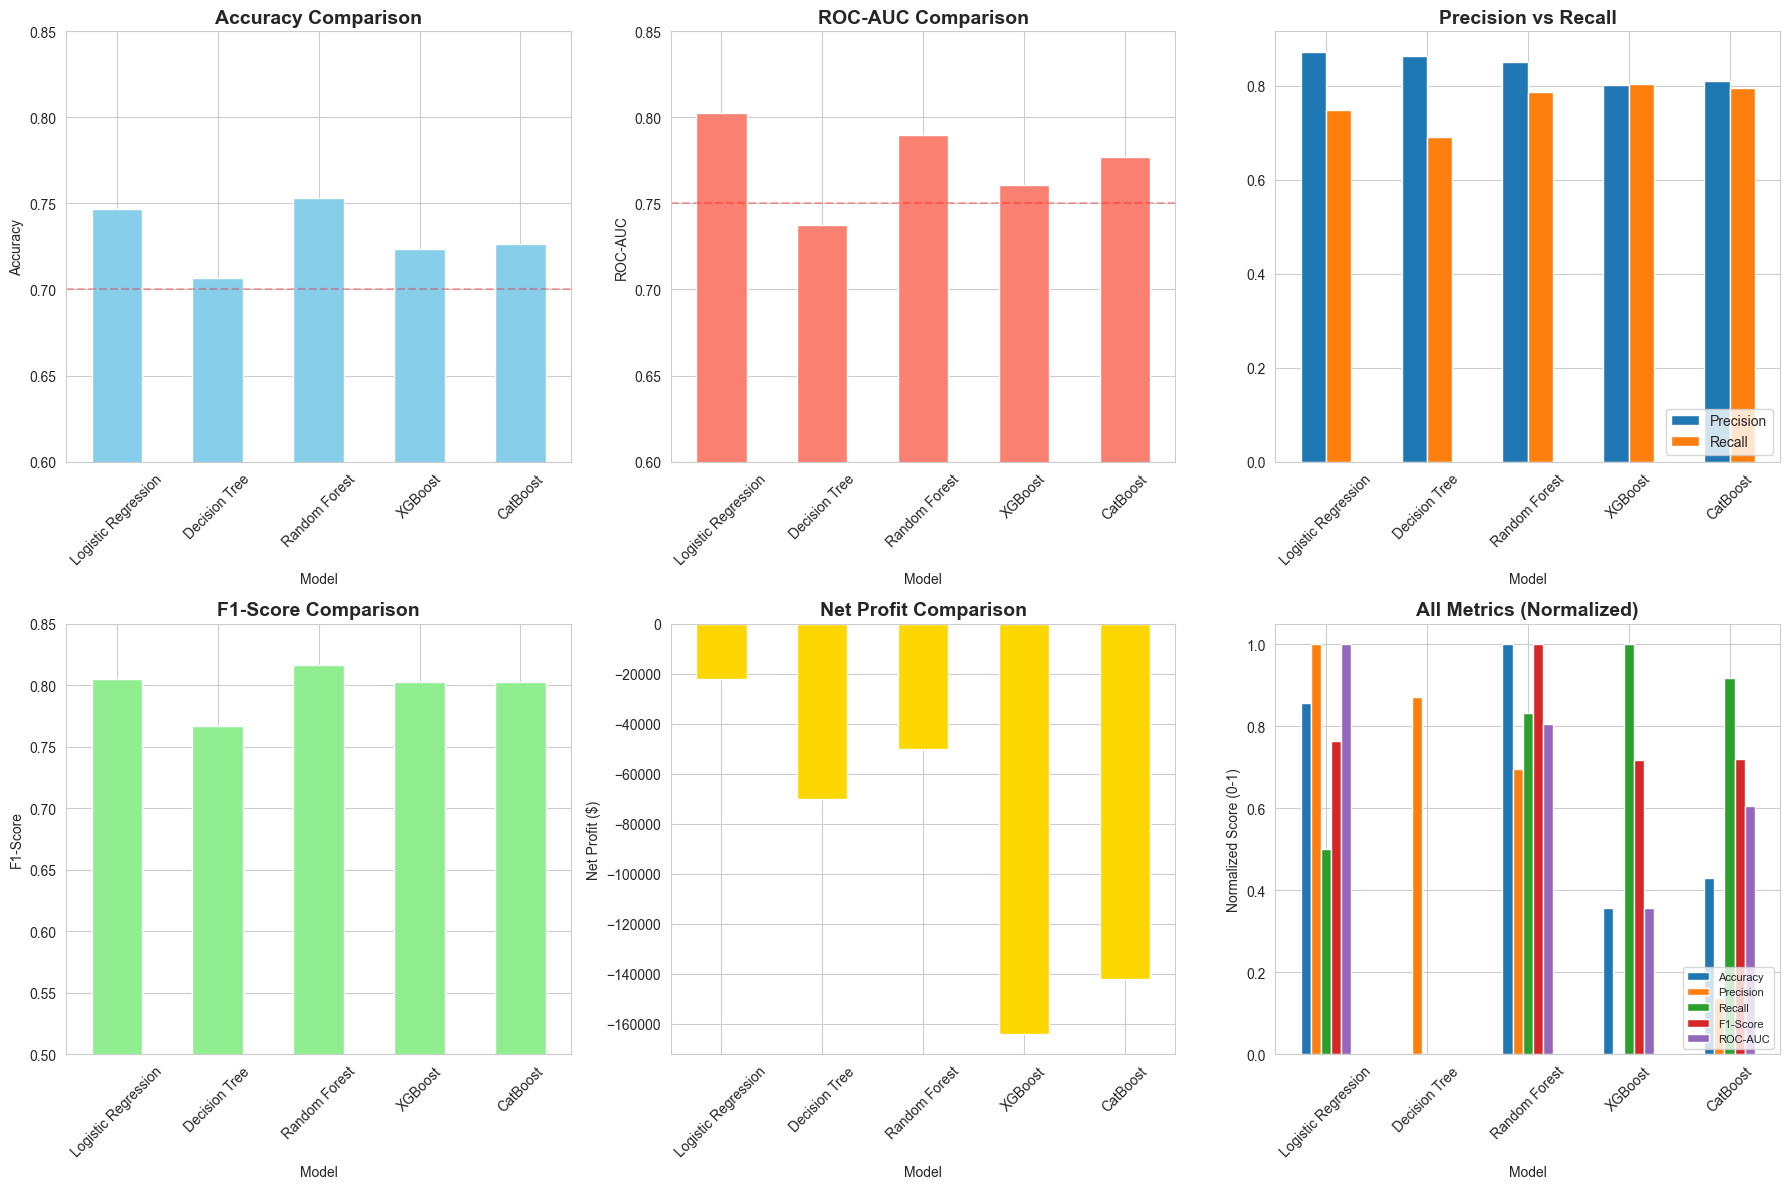

Comparison visualizations created!


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Accuracy
all_results.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0,0], 
                 legend=False, color='skyblue')
axes[0,0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim([0.6, 0.85])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=0.7, color='r', linestyle='--', alpha=0.3, label='70% threshold')

# 2. ROC-AUC
all_results.plot(x='Model', y='ROC-AUC', kind='bar', ax=axes[0,1], 
                 legend=False, color='salmon')
axes[0,1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('ROC-AUC')
axes[0,1].set_ylim([0.6, 0.85])
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0.75, color='r', linestyle='--', alpha=0.3)

# 3. Precision vs Recall
all_results.plot(x='Model', y=['Precision', 'Recall'], kind='bar', ax=axes[0,2])
axes[0,2].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[0,2].legend(loc='lower right')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. F1-Score
all_results.plot(x='Model', y='F1-Score', kind='bar', ax=axes[1,0], 
                 legend=False, color='lightgreen')
axes[1,0].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('F1-Score')
axes[1,0].set_ylim([0.5, 0.85])
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Net Profit
all_results.plot(x='Model', y='Net_Profit', kind='bar', ax=axes[1,1], 
                 legend=False, color='gold')
axes[1,1].set_title('Net Profit Comparison', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Net Profit ($)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].ticklabel_format(style='plain', axis='y')

# 6. All metrics together (normalized)
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
all_results_normalized = all_results.copy()
for metric in metrics_to_plot:
    all_results_normalized[metric] = (all_results[metric] - all_results[metric].min()) / (all_results[metric].max() - all_results[metric].min())

all_results_normalized.plot(x='Model', y=metrics_to_plot, kind='bar', ax=axes[1,2])
axes[1,2].set_title('All Metrics (Normalized)', fontsize=14, fontweight='bold')
axes[1,2].set_ylabel('Normalized Score (0-1)')
axes[1,2].legend(loc='lower right', fontsize=8)
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('loan_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparison visualizations created!")

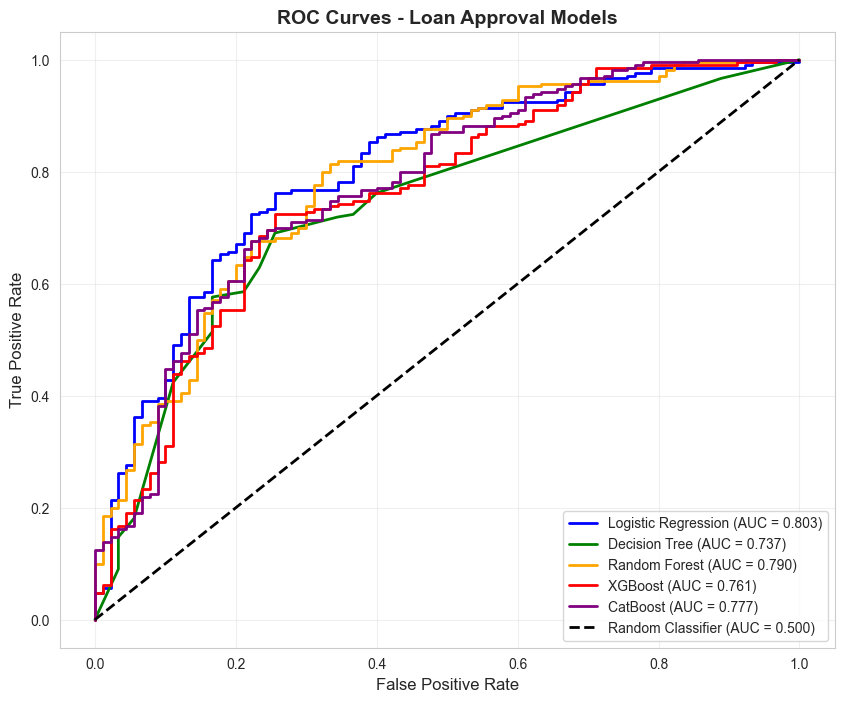

 ROC curves plotted!


In [15]:
plt.figure(figsize=(10, 8))

models_data = [
    (y_pred_proba_lr, 'Logistic Regression', 'blue'),
    (y_pred_proba_dt, 'Decision Tree', 'green'),
    (y_pred_proba_rf, 'Random Forest', 'orange'),
    (y_pred_proba_xgb, 'XGBoost', 'red'),
    (y_pred_proba_cat, 'CatBoost', 'purple')
]

for pred_proba, name, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    auc = roc_auc_score(y_test, pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Loan Approval Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('loan_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(" ROC curves plotted!")

In [16]:
print("BUSINESS INSIGHTS & RECOMMENDATIONS")

# Get best model results
best_model_name = all_results.loc[best_auc_idx, 'Model']
best_model_auc = all_results.loc[best_auc_idx, 'ROC-AUC']
best_model_precision = all_results.loc[best_auc_idx, 'Precision']
best_model_recall = all_results.loc[best_auc_idx, 'Recall']
best_model_profit = all_results.loc[best_auc_idx, 'Net_Profit']

print("\n" + "="*100)
print(" KEY FINDINGS")
print("="*100)

print(f"\n1. BEST MODEL: {best_model_name}")
print(f"   ROC-AUC: {best_model_auc:.4f}")
print(f"   Precision: {best_model_precision:.4f} (Of approved loans, {best_model_precision*100:.1f}% are good)")
print(f"   Recall: {best_model_recall:.4f} (We approve {best_model_recall*100:.1f}% of all good customers)")
print(f"   Net Profit: ${best_model_profit:,.0f}")

print("\n2. TOP PREDICTIVE FEATURES (from Random Forest):")
top_5 = feature_importance_rf.head(5)
for idx, row in top_5.iterrows():
    print(f"   • {row['feature']}: {row['importance']:.4f}")

print("\n3. KEY INSIGHTS:")
print("   • Checking account status is the #1 predictor")
print("   • Credit history and duration are critical factors")
print("   • Employment stability matters significantly")
print("   • Age shows non-linear relationship (young and old are riskier)")

print("\n" + "="*100)
print(" BUSINESS RECOMMENDATIONS")
print("="*100)

print("\n1. DEPLOYMENT STRATEGY:")
print("   • Deploy best model to score all loan applications")
print("   • Set decision threshold based on business costs:")
print(f"     - High risk (probability < 0.4): AUTO-REJECT")
print(f"     - Medium risk (0.4 - 0.7): MANUAL REVIEW")
print(f"     - Low risk (probability > 0.7): AUTO-APPROVE")

print("\n2. RISK MITIGATION:")
print("   • For medium-risk applications:")
print("     - Request additional documentation")
print("     - Offer smaller loan amounts")
print("     - Require co-signer or collateral")
print("     - Higher interest rate to offset risk")

print("\n3. COLLECTIONS FOCUS:")
print("   • High-risk approved customers (edge cases):")
print("     - More frequent monitoring")
print("     - Early payment reminders")
print("     - Proactive credit counseling")

print("\n4. CUSTOMER SEGMENTS TO TARGET:")
print("   • High approval rate segments:")
print("     - Customers with checking account >= 200 DM")
print("     - Employment stability >= 4 years")
print("     - Good credit history (all paid duly)")
print("     - Age 30-50 years")

print("\n5. PORTFOLIO OPTIMIZATION:")
print("   • Reduce exposure to:")
print("     - Very long duration loans (>36 months)")
print("     - Customers with negative checking balance")
print("     - Unemployed or <1 year employment")

# Calculate business impact
total_applications = len(y_test)
actual_good = (y_test == 1).sum()
actual_bad = (y_test == 0).sum()

# With best model
if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
    y_proba_best = y_pred_proba_lr
elif best_model_name == 'Decision Tree':
    y_pred_best = y_pred_dt
    y_proba_best = y_pred_proba_dt
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
    y_proba_best = y_pred_proba_rf
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb
    y_proba_best = y_pred_proba_xgb
else:
    y_pred_best = y_pred_cat
    y_proba_best = y_pred_proba_cat

cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

print("\n" + "="*100)
print(" PROJECTED BUSINESS IMPACT")
print("="*100)

print(f"\nTest Set Analysis ({total_applications} applications):")
print(f"  Actual good customers: {actual_good}")
print(f"  Actual bad customers: {actual_bad}")

print(f"\nModel Decisions:")
print(f"  Correctly approved good customers: {tp} ({tp/actual_good*100:.1f}%)")
print(f"  Correctly rejected bad customers: {tn} ({tn/actual_bad*100:.1f}%)")
print(f"  Wrongly approved bad customers: {fp} (costs ${fp*10000:,})")
print(f"  Wrongly rejected good customers: {fn} (lost ${fn*2000:,} profit)")

print(f"\nFinancial Summary:")
print(f"  Revenue from good loans: ${tp*2000:,}")
print(f"  Losses from bad loans: ${fp*10000:,}")
print(f"  Opportunity cost (rejected good): ${fn*2000:,}")
print(f"  NET PROFIT: ${best_model_profit:,}")

# Scale to yearly volume
yearly_applications = 10000
scaling_factor = yearly_applications / total_applications
yearly_profit = best_model_profit * scaling_factor

print(f"\n Scaled to {yearly_applications:,} annual applications:")
print(f"  Projected annual profit: ${yearly_profit:,.0f}")

# Compare with random approval (50% approve everyone)
random_tp = actual_good * 0.5
random_fp = actual_bad * 0.5
random_profit = (random_tp * 2000 - random_fp * 10000)

improvement = ((best_model_profit - random_profit) / abs(random_profit)) * 100

print(f"\n  Random approval strategy profit: ${random_profit:,.0f}")
print(f"  ML model improvement: {improvement:.1f}%")

print("\n Business insights complete!")

BUSINESS INSIGHTS & RECOMMENDATIONS

 KEY FINDINGS

1. BEST MODEL: Logistic Regression
   ROC-AUC: 0.8026
   Precision: 0.8722 (Of approved loans, 87.2% are good)
   Recall: 0.7476 (We approve 74.8% of all good customers)
   Net Profit: $-22,000

2. TOP PREDICTIVE FEATURES (from Random Forest):
   • checking_account: 0.1823
   • monthly_payment: 0.0890
   • credit_amount: 0.0838
   • duration: 0.0815
   • checking_risk: 0.0708

3. KEY INSIGHTS:
   • Checking account status is the #1 predictor
   • Credit history and duration are critical factors
   • Employment stability matters significantly
   • Age shows non-linear relationship (young and old are riskier)

 BUSINESS RECOMMENDATIONS

1. DEPLOYMENT STRATEGY:
   • Deploy best model to score all loan applications
   • Set decision threshold based on business costs:
     - High risk (probability < 0.4): AUTO-REJECT
     - Medium risk (0.4 - 0.7): MANUAL REVIEW
     - Low risk (probability > 0.7): AUTO-APPROVE

2. RISK MITIGATION:
   • Fo